In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [86]:
data = pd.read_csv("Salary_Data.csv")

In [87]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [88]:
x = data.iloc[:, :-1]
y = data.iloc[:, 1]
print(f"x:{x}\ny:{y}")

x:    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5
y:0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
2

In [89]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state = 10)

In [90]:
poly = PolynomialFeatures(degree = 20) #it goes from x to x^15
x_poly_train = poly.fit_transform(x_train) # fit gets the data and transform applies it
x_poly_test = poly.transform(x_test)

In [91]:
x_poly_test

array([[1.00000000e+00, 6.80000000e+00, 4.62400000e+01, 3.14432000e+02,
        2.13813760e+03, 1.45393357e+04, 9.88674826e+04, 6.72298882e+05,
        4.57163240e+06, 3.10871003e+07, 2.11392282e+08, 1.43746752e+09,
        9.77477912e+09, 6.64684980e+10, 4.51985787e+11, 3.07350335e+12,
        2.08998228e+13, 1.42118795e+14, 9.66407805e+14, 6.57157307e+15,
        4.46866969e+16],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02, 3.35544320e+02, 1.07374182e+03, 3.43597384e+03,
        1.09951163e+04, 3.51843721e+04, 1.12589991e+05, 3.60287970e+05,
        1.15292150e+06, 3.68934881e+06, 1.18059162e+07, 3.77789319e+07,
        1.20892582e+08, 3.86856262e+08, 1.23794004e+09, 3.96140813e+09,
        1.26765060e+10],
       [1.00000000e+00, 2.90000000e+00, 8.41000000e+00, 2.43890000e+01,
        7.07281000e+01, 2.05111490e+02, 5.94823321e+02, 1.72498763e+03,
        5.00246413e+03, 1.45071460e+04, 4.20707233e+04, 1.22005098e+05,
        3.5381

In [92]:
poly_model = LinearRegression()
poly_model.fit(x_poly_train, y_train)
y_poly_pred_train = poly_model.predict(x_poly_train)
y_poly_pred_test = poly_model.predict(x_poly_test)

In [93]:
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
x_range_pred = poly_model.predict(x_range_poly)

c:\Users\OC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [94]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9356.86]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.609e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


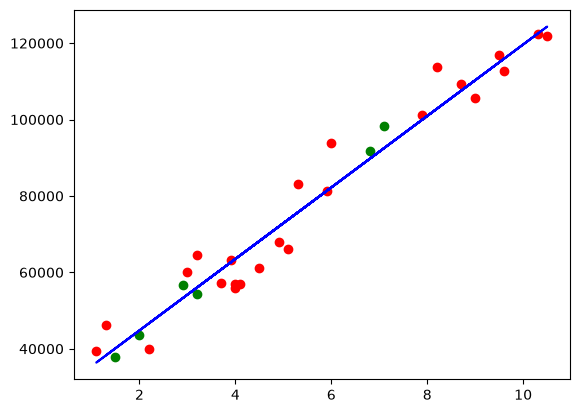

In [95]:
plt.scatter(x_train, y_train, color = "red")
plt.scatter(x_test, y_test, color = "green", label = "Test Data")
plt.plot(x_train, lin_reg.predict(x_train), color = "Blue")

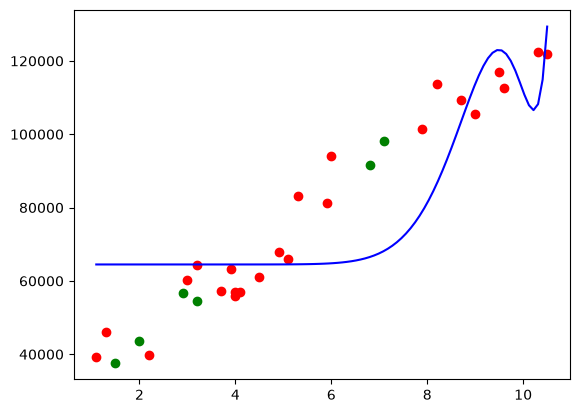

In [96]:
plt.scatter(x_train, y_train, color = "red")
plt.scatter(x_test, y_test, color = "green", label = "Test Data")
plt.plot(x_range, x_range_pred, color = "Blue", label = "Poly Regression")

In [97]:
y_lin_pred_train = lin_reg.predict(x_train)
y_lin_pred_test = lin_reg.predict(x_test)
train_lin_r2 = r2_score(y_train, y_lin_pred_train)
test_lin_r2 = r2_score(y_test, y_lin_pred_test)
print(train_lin_r2)
print(test_lin_r2)

0.9494673013344644
0.9816423482070253


In [98]:
train_lin_r2 = r2_score(y_train, y_poly_pred_train)
test_lin_r2 = r2_score(y_test, y_poly_pred_test)
print(train_lin_r2)
print(test_lin_r2)

0.7095933963550956
0.10597296515825194
